Ísis Ardissom Logullo - 7577410

Exercício 23 - Lista 1

Importação de Bibliotecas e Download da Imagem

Downloading...
From: https://drive.google.com/uc?id=1ghbxSygluI94rbOh5HC8nQi9ML9h_QQX
To: /content/imagem_original.tif
100%|██████████| 243k/243k [00:00<00:00, 61.1MB/s]


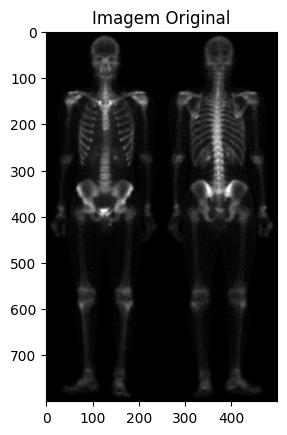

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gdown

url = 'https://drive.google.com/uc?id=1ghbxSygluI94rbOh5HC8nQi9ML9h_QQX'
output = 'imagem_original.tif'
gdown.download(url, output, quiet=False)

img_original = plt.imread(output).astype(np.float64)
if img_original.max() > 1.0:
    img_original /= 255.0

plt.imshow(img_original, cmap='gray')
plt.title("Imagem Original")
plt.show()

Convolução 2D

Função de convolução tratando as bordas com preenchimento de zeros

In [3]:
def convolucao(image, kernel):
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape
    pad_h = ker_h // 2
    pad_w = ker_w // 2

    img_padded = np.zeros((img_h + 2*pad_h, img_w + 2*pad_w))
    img_padded[pad_h:-pad_h, pad_w:-pad_w] = image

    kernel = np.flipud(np.fliplr(kernel))
    output = np.zeros_like(image)

    for i in range(img_h):
        for j in range(img_w):
            regiao = img_padded[i:i+ker_h, j:j+ker_w]
            output[i, j] = np.sum(regiao * kernel)

    return output

Operador Laplaciano

Utilizado o kernel Laplaciano $3 \times 3$ com vizinhança 8 para destacar detalhes finos da imagem.

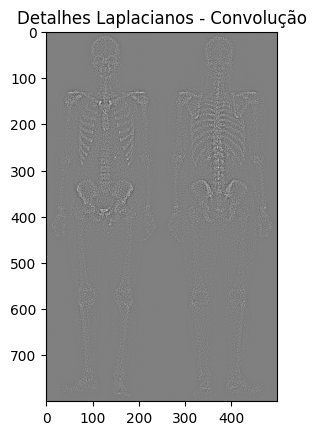

In [5]:
w_lap = np.array([[-1, -1, -1],
                  [-1,  8, -1],
                  [-1, -1, -1]])

img_lap = convolucao(img_original, w_lap)

plt.imshow(img_lap, cmap='gray')
plt.title("Detalhes Laplacianos - Convolução")
plt.show()

Gradiente de Sobel (Magnitude)

Usado os kernels de Sobel para identificar as bordas proeminentes, calculando a magnitude do gradiente.

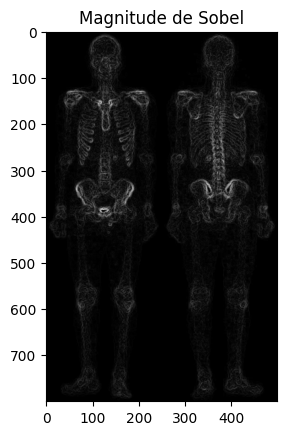

In [6]:
gx_kernel = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]])

gy_kernel = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]])

img_gx = convolucao(img_original, gx_kernel)
img_gy = convolucao(img_original, gy_kernel)
img_sobel = np.sqrt(img_gx**2 + img_gy**2)

plt.imshow(img_sobel, cmap='gray')
plt.title("Magnitude de Sobel")
plt.show()

Suavização da Máscara (Box Filter)

Aplicado filtro de média $5 \times 5$ para reduzir o ruído na máscara de Sobel antes da combinação final.

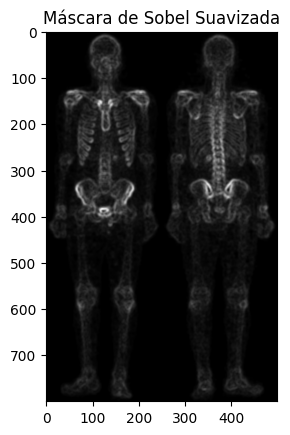

In [8]:
w_box = np.ones((5, 5)) / 25.0
mask_smooth = convolucao(img_sobel, w_box)

plt.imshow(mask_smooth, cmap='gray')
plt.title("Máscara de Sobel Suavizada")
plt.show()

Combinação de Resultados

Combinando a imagem original com o produto Laplaciano e a máscara de Sobel suavizada. Isso garante que o realce ocorra apenas nas bordas estruturais.

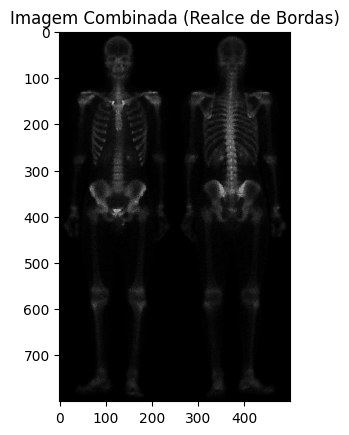

In [11]:
img_combinada = img_original + (img_lap * mask_smooth)
img_combinada = np.clip(img_combinada, 0, None)

plt.imshow(img_combinada, cmap='gray')
plt.title("Imagem Combinada (Realce de Bordas)")
plt.show()

Transformação de Potência (Gamma)

Correção Gamma para ajustar o contraste e aumentar o brilho das regiões de baixa intensidade.

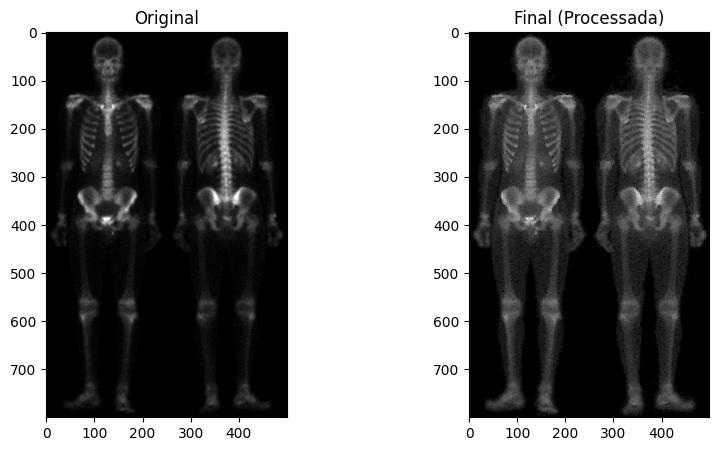

In [10]:
c = 1.0
gamma = 0.5

img_final = c * (img_combinada ** gamma)
img_final = (img_final - img_final.min()) / (img_final.max() - img_final.min())

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_original, cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(img_final, cmap='gray')
plt.title("Final (Processada)")
plt.show()